In [10]:
# Imports
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from UserBasedCF_NaiveAlgorithm import UserBasedCF
from MatrixFactorization_OptimizedAlgorithm import MatrixFactorization

In [12]:
# Load Dataset (MovieLens format)
ratings_df = pd.read_csv(
"u.data",
sep="\t",
names=["user_id", "item_id", "rating", "timestamp"]
)[["user_id", "item_id", "rating"]]

print(ratings_df.head())
print("Total ratings:", len(ratings_df))

   user_id  item_id  rating
0      196      242       3
1      186      302       3
2       22      377       1
3      244       51       2
4      166      346       1
Total ratings: 100000


In [13]:
# Train / Test Split
train = pd.read_csv(
"u1.base", sep="\t",
names=["user_id","item_id","rating","timestamp"]
)[["user_id","item_id","rating"]]

test = pd.read_csv(
"u1.test", sep="\t",
names=["user_id","item_id","rating","timestamp"]
)[["user_id","item_id","rating"]]

In [16]:
# Evaluation Function

def evaluate(model, df):
    preds = []
    actual = []

    for _, row in df.iterrows():
        preds.append(model.predict(row['user_id'], row['item_id']))
        actual.append(row['rating'])

    return mean_squared_error(actual, preds, squared=False)

In [17]:
# Train and Evaluate UBCF

ubcf = UserBasedCF(k=5)
start = time.time()
ubcf.fit(train)
ubcf_train_time = time.time() - start

start = time.time()
rmse_ubcf = evaluate(ubcf, test)
ubcf_test_time = time.time() - start

print("UBCF RMSE:", rmse_ubcf)
print("UBCF Train Time:", ubcf_train_time)
print("UBCF Test Time:", ubcf_test_time)

UBCF RMSE: 1.071513746081088
UBCF Train Time: 0.1872565746307373
UBCF Test Time: 13.347066879272461


In [51]:
# Train and Evaluate MF

mf = MatrixFactorization(
    n_factors=80,       
    learning_rate=0.003,
    reg=0.02,
    n_iters=100    
)

start = time.time()
mf.fit(train)
mf_train_time = time.time() - start

start = time.time()
rmse_mf = evaluate(mf, test)
mf_test_time = time.time() - start

print("MF RMSE:", rmse_mf)
print("MF Train Time:", mf_train_time)
print("MF Test Time:", mf_test_time)

MF RMSE: 0.9364533230495088
MF Train Time: 928.8485085964203
MF Test Time: 1.809737205505371


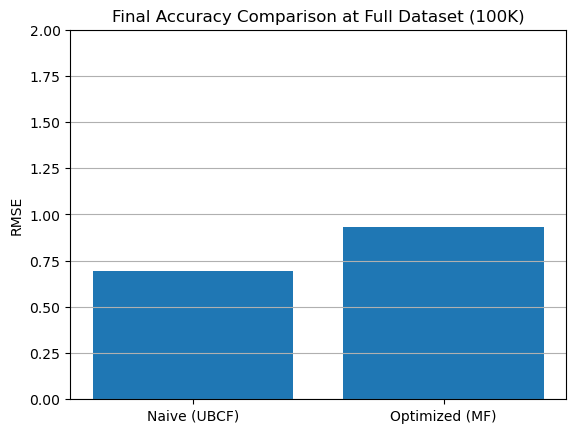

In [86]:
import matplotlib.pyplot as plt

ubcf_rmse = rmse_ubcf
mf_rmse = rmse_mf

plt.figure()
plt.bar(["Naive (UBCF)", "Optimized (MF)"], [ubcf_rmse, mf_rmse])
plt.ylabel("RMSE")
plt.title("Final Accuracy Comparison at Full Dataset (100K)")
plt.ylim(0, 2)   # zoomed but honest
plt.grid(True, axis="y")
plt.show()


In [52]:
# Varying Input Size Experiment

sizes = [10000, 30000, 60000, 100000]
results = []

for size in sizes:
    subset = ratings_df.sample(n=size, random_state=42)

    ubcf = UserBasedCF(k=5)
    start = time.time()
    ubcf.fit(subset)
    ubcf_train_time = time.time() - start

    start = time.time()
    rmse_ubcf = evaluate(ubcf, subset)
    ubcf_test_time = time.time() - start

    mf = MatrixFactorization(n_factors=10, learning_rate=0.01, reg=0.02, n_iters=5)
    start = time.time()
    mf.fit(subset)
    mf_train_time = time.time() - start

    start = time.time()
    rmse_mf = evaluate(mf, subset)
    mf_test_time = time.time() - start

    results.append([
        size,
        ubcf_train_time, ubcf_test_time, rmse_ubcf,
        mf_train_time, mf_test_time, rmse_mf
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Data Size",
        "UBCF Train Time", "UBCF Test Time", "UBCF RMSE",
        "MF Train Time", "MF Test Time", "MF RMSE"
    ]
)

print(results_df)

   Data Size  UBCF Train Time  UBCF Test Time  UBCF RMSE  MF Train Time  \
0      10000         0.108384        5.757074   0.386985       7.086908   
1      30000         0.108748       17.628503   0.463712      21.131147   
2      60000         0.131010       37.974908   0.587569      39.586363   
3     100000         0.161484       64.515661   0.693482      64.497084   

   MF Test Time   MF RMSE  
0      0.955480  3.529581  
1      3.041977  1.309592  
2      5.921356  0.976175  
3      9.381108  0.932141  


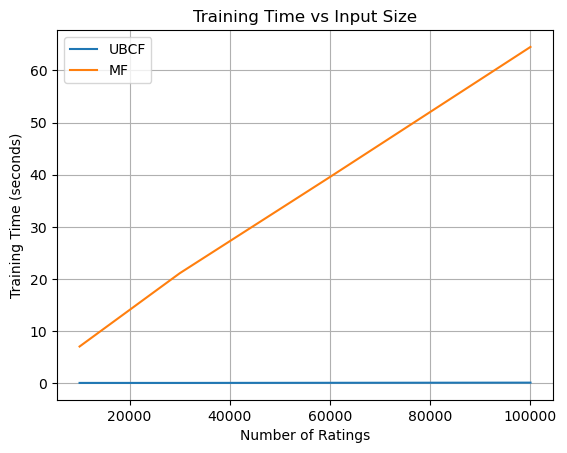

In [78]:
# Plot Training Time vs Input Size

plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF Train Time"], label="UBCF")
plt.plot(results_df["Data Size"], results_df["MF Train Time"], label="MF")
plt.xlabel("Number of Ratings")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs Input Size")
plt.legend()
plt.grid(True)
plt.show()

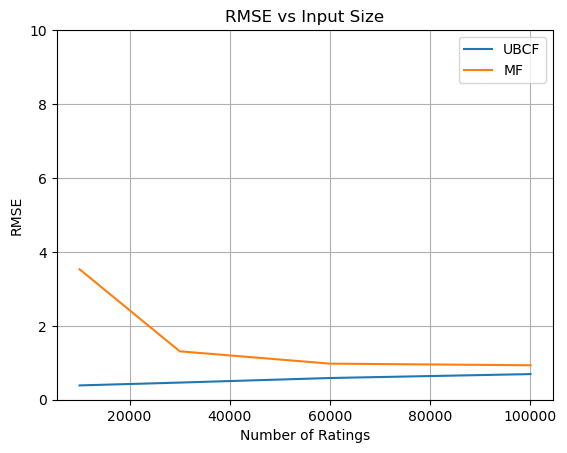

In [79]:
# Plot RMSE vs Input Size

plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF RMSE"], label="UBCF")
plt.plot(results_df["Data Size"], results_df["MF RMSE"], label="MF")
plt.xlabel("Number of Ratings")
plt.ylabel("RMSE")
plt.title("RMSE vs Input Size")
plt.legend()
plt.grid(True)
plt.ylim(0, 10)
plt.show()

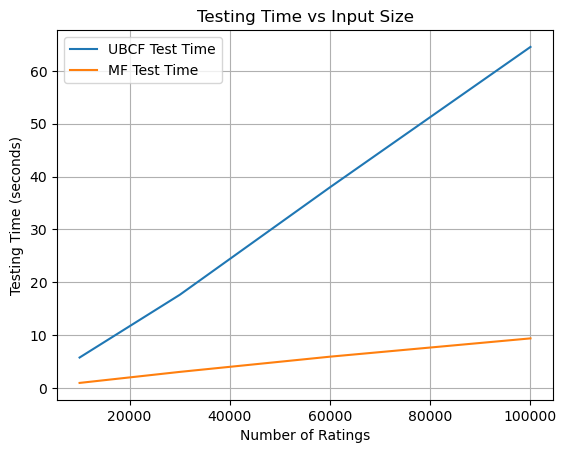

In [80]:
# Testing Time vs Input Size

plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF Test Time"], label="UBCF Test Time")
plt.plot(results_df["Data Size"], results_df["MF Test Time"], label="MF Test Time")
plt.xlabel("Number of Ratings")
plt.ylabel("Testing Time (seconds)")
plt.title("Testing Time vs Input Size")
plt.legend()
plt.grid(True)
plt.show()

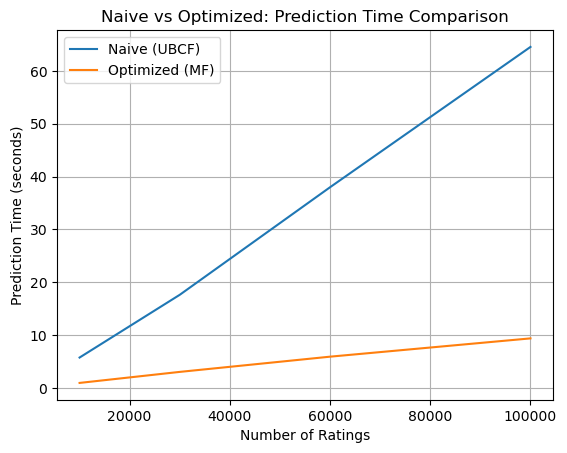

In [58]:
plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF Test Time"], label="Naive (UBCF)")
plt.plot(results_df["Data Size"], results_df["MF Test Time"], label="Optimized (MF)")
plt.xlabel("Number of Ratings")
plt.ylabel("Prediction Time (seconds)")
plt.title("Naive vs Optimized: Prediction Time Comparison")
plt.legend()
plt.grid(True)
plt.show()

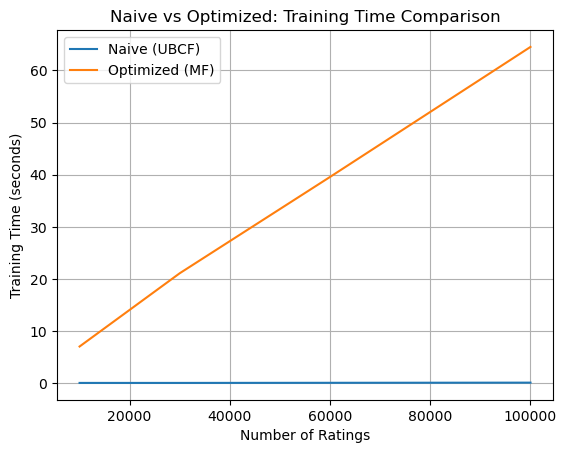

In [59]:
plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF Train Time"], label="Naive (UBCF)")
plt.plot(results_df["Data Size"], results_df["MF Train Time"], label="Optimized (MF)")
plt.xlabel("Number of Ratings")
plt.ylabel("Training Time (seconds)")
plt.title("Naive vs Optimized: Training Time Comparison")
plt.legend()
plt.grid(True)
plt.show()

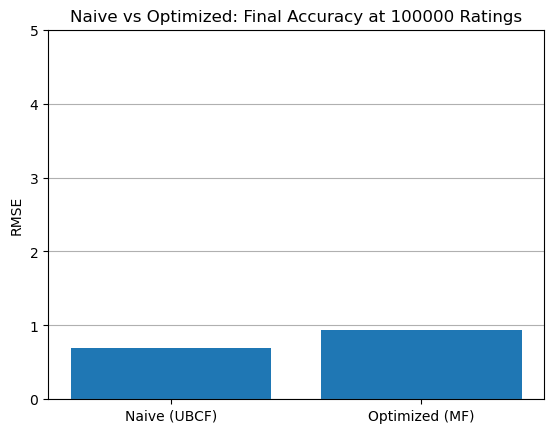

In [81]:
# Final RMSE Comparison at Full Data (Correct Naive vs Optimized)

final_ubcf = results_df["UBCF RMSE"].iloc[-1]
final_mf   = results_df["MF RMSE"].iloc[-1]
final_size = results_df["Data Size"].iloc[-1]

plt.figure()
plt.bar(["Naive (UBCF)", "Optimized (MF)"],
        [final_ubcf, final_mf])
plt.ylabel("RMSE")
plt.title(f"Naive vs Optimized: Final Accuracy at {final_size} Ratings")
plt.grid(True, axis="y")
plt.ylim(0, 5)
plt.show()

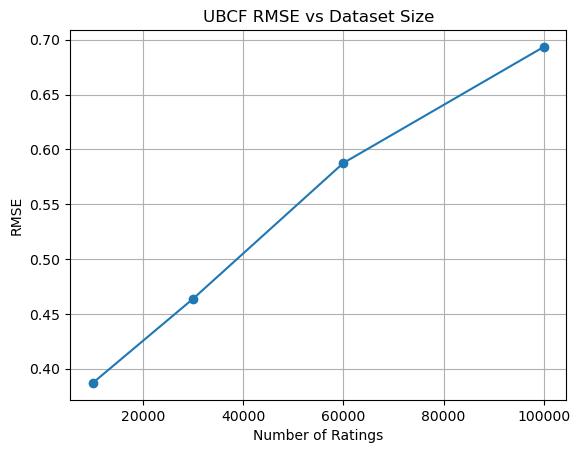

In [73]:
plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF RMSE"], marker="o")
plt.xlabel("Number of Ratings")
plt.ylabel("RMSE")
plt.title("UBCF RMSE vs Dataset Size")
plt.grid(True)

plt.show()

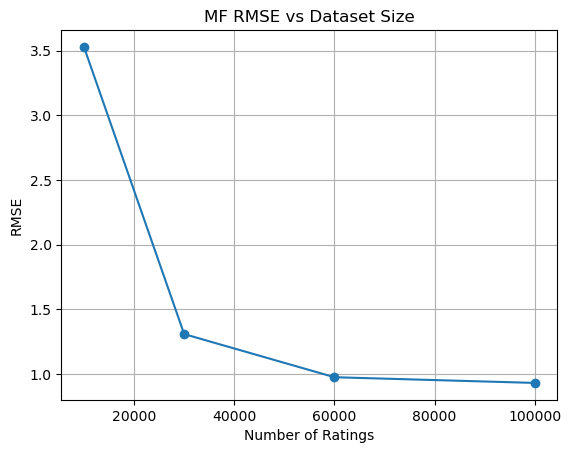

In [62]:
plt.figure()
plt.plot(results_df["Data Size"], results_df["MF RMSE"], marker="o")
plt.xlabel("Number of Ratings")
plt.ylabel("RMSE")
plt.title("MF RMSE vs Dataset Size")
plt.grid(True)
plt.show()

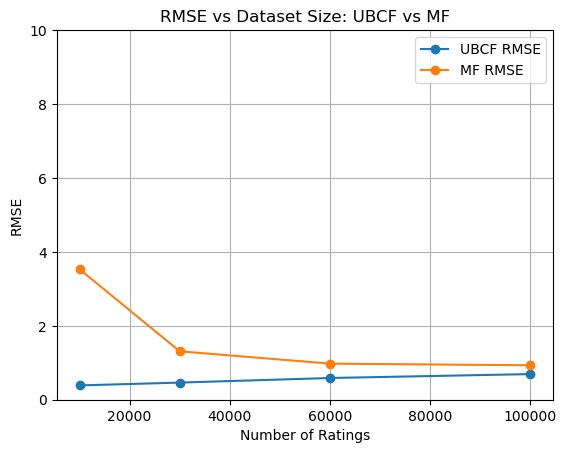

In [71]:
plt.figure()
plt.plot(results_df["Data Size"], results_df["UBCF RMSE"], marker="o", label="UBCF RMSE")
plt.plot(results_df["Data Size"], results_df["MF RMSE"], marker="o", label="MF RMSE")
plt.xlabel("Number of Ratings")
plt.ylabel("RMSE")
plt.title("RMSE vs Dataset Size: UBCF vs MF")
plt.legend()
plt.grid(True)

plt.ylim(0, 10)
plt.show()

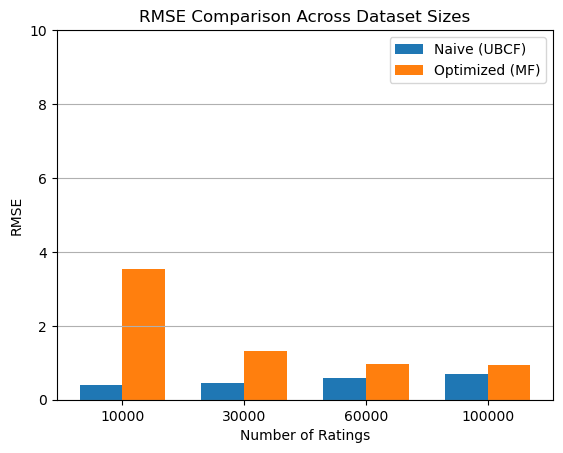

In [67]:
import numpy as np
import matplotlib.pyplot as plt

data_sizes = results_df["Data Size"]
ubcf_rmse = results_df["UBCF RMSE"]
mf_rmse = results_df["MF RMSE"]

x = np.arange(len(data_sizes)) 
width = 0.35   

plt.figure()
plt.bar(x - width/2, ubcf_rmse, width, label="Naive (UBCF)")
plt.bar(x + width/2, mf_rmse, width, label="Optimized (MF)")

plt.xlabel("Number of Ratings")
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Dataset Sizes")
plt.xticks(x, data_sizes)
plt.legend()
plt.grid(True, axis="y")

plt.ylim(0, 10)
plt.show()

In [82]:
results_df.style.set_caption("Performance Comparison of UBCF and MF") \
                .format("{:.4f}") \
                .set_properties(**{
                    "text-align": "center",
                    "border": "1px solid black"
                })

,Data Size,UBCF Train Time,UBCF Test Time,UBCF RMSE,MF Train Time,MF Test Time,MF RMSE
0,10000.0000,0.1084,5.7571,0.3870,7.0869,0.9555,3.5296
1,30000.0000,0.1087,17.6285,0.4637,21.1311,3.0420,1.3096
2,60000.0000,0.1310,37.9749,0.5876,39.5864,5.9214,0.9762
3,100000.0000,0.1615,64.5157,0.6935,64.4971,9.3811,0.9321
